# Notebook 160: 言語モデリングの基礎 — N-gramから確率論的LMへ

| 項目 | 内容 |
|------|------|
| **難易度** | ★★☆☆☆ |
| **推定時間** | 90-120 min |
| **カテゴリ** | 言語モデル |
| **前提知識** | Notebook 151 (Word2Vec / 分布仮説) |

---

## 学習目標

 このノートブックを完了すると、以下ができるようになります：

- [ ] 言語モデルの定義 $P(w_1, w_2, \ldots, w_n)$ を説明できる
- [ ] Unigram / Bigram / Trigram モデルをスクラッチ実装できる
- [ ] 連鎖律とマルコフ仮定の関係を理解できる
- [ ] スムージング手法（ラプラス、Kneser-Ney 概要）を適用できる
- [ ] パープレキシティを定義・計算・直感的に理解できる
- [ ] N-gram モデルの限界と神経言語モデルへの動機を説明できる

---
# ============================================================
# セクション 1: 環境セットアップ
# ============================================================

In [1]:
# ============================================================
# セクション 1: 環境セットアップ
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
from collections import Counter, defaultdict
import math

# --- 再現性の確保 ---
np.random.seed(42)

# --- 警告を非表示 ---
warnings.filterwarnings('ignore')

# --- 日本語フォント設定関数 ---
def setup_japanese_font():
    """matplotlib で日本語フォントを使用するための設定"""
    # macOS の場合
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'Meiryo', 'IPAexGothic', 'Noto Sans CJK JP'
    ]
    for font in japanese_fonts:
        try:
            matplotlib.font_manager.findfont(font, fallback_to_default=False)
            plt.rcParams['font.family'] = font
            print(f"日本語フォント設定完了: {font}")
            return
        except Exception:
            continue
    print("警告: 日本語フォントが見つかりません。デフォルトフォントを使用します。")

setup_japanese_font()

# --- プロットスタイル設定 ---
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("セットアップ完了!")

C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


日本語フォント設定完了: Yu Gothic
セットアップ完了!


---
# ============================================================
# セクション 2: 言語モデルとは何か
# ============================================================

## 2.1 言語モデルの定義

**言語モデル（Language Model, LM）** とは、単語列（文）に確率を割り当てるモデルです。

$$P(w_1, w_2, \ldots, w_n)$$

この確率が高いほど、その単語列は「自然な文」である可能性が高いと判断します。

### 実世界での応用例

| 応用分野 | 言語モデルの役割 |
|----------|------------------|
| **自動補完** | 「今日の天気は」→ 次に来る単語の候補を確率でランク付け |
| **音声認識** | 音響的に曖昧な入力を、確率的に最も自然な文に変換 |
| **機械翻訳** | 翻訳候補の中から最も自然な文を選択 |
| **スペルチェック** | 誤字を含む文 vs 正しい文の確率を比較 |

## 2.2 連鎖律（Chain Rule）による分解

確率の連鎖律を使うと、同時確率を条件付き確率の積に分解できます：

$$P(w_1, w_2, \ldots, w_n) = P(w_1) \cdot P(w_2|w_1) \cdot P(w_3|w_1, w_2) \cdots P(w_n|w_1, \ldots, w_{n-1})$$

$$= \prod_{i=1}^{n} P(w_i | w_1, \ldots, w_{i-1})$$

しかし、$P(w_n | w_1, \ldots, w_{n-1})$ を正確に推定するには膨大なデータが必要です。

## 2.3 マルコフ仮定

そこで **マルコフ仮定** を導入します。直前の $k$ 個の単語のみに依存すると仮定します：

- **Unigram（$k=0$）**: $P(w_i | w_1, \ldots, w_{i-1}) \approx P(w_i)$
- **Bigram（$k=1$）**: $P(w_i | w_1, \ldots, w_{i-1}) \approx P(w_i | w_{i-1})$
- **Trigram（$k=2$）**: $P(w_i | w_1, \ldots, w_{i-1}) \approx P(w_i | w_{i-2}, w_{i-1})$

これが **N-gram 言語モデル** の基本的なアイデアです。

In [2]:
# ============================================================
# セクション 2: コーパスの準備
# ============================================================

# デモ用の小さな英語コーパス（おとぎ話風の短文）
# N-gram のアルゴリズムは言語に依存しないため、英語で実装を示します

# --- 学習用コーパス（20文）---
train_corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat chased the mouse",
    "the dog chased the cat",
    "a bird sat on the tree",
    "the cat and the dog played in the garden",
    "the mouse ran under the table",
    "a small cat sat on a big mat",
    "the dog and the cat are friends",
    "the bird sang a beautiful song",
    "the cat slept on the warm mat",
    "a dog ran in the garden",
    "the mouse hid under the mat",
    "the cat watched the bird on the tree",
    "a big dog chased a small cat",
    "the garden had many beautiful flowers",
    "the cat and the mouse played a game",
    "the dog slept on the rug near the fire",
    "a bird sang on the tree in the morning",
    "the cat sat and watched the garden",
]

# --- テスト用コーパス ---
test_corpus = [
    "the cat sat on the rug",
    "a dog chased the bird",
    "the mouse ran under the table",
]

# --- テキストの前処理関数 ---
def tokenize(sentence):
    """文をトークン化し、<s>（文頭）と </s>（文末）を付与する"""
    # 小文字化してスペースで分割
    tokens = sentence.lower().strip().split()
    return tokens

def add_markers(tokens, n=2):
    """N-gram モデル用に文頭・文末マーカーを付与する
    
    Args:
        tokens: トークンのリスト
        n: N-gram の N（文頭マーカーを n-1 個追加）
    Returns:
        マーカー付きトークンリスト
    """
    return ['<s>'] * (n - 1) + tokens + ['</s>']

# --- コーパス全体をトークン化 ---
train_tokens_list = [tokenize(s) for s in train_corpus]

# 語彙の構築
all_tokens = [token for tokens in train_tokens_list for token in tokens]
vocab = sorted(set(all_tokens))
vocab_with_markers = sorted(set(all_tokens + ['<s>', '</s>']))

print(f"学習コーパス: {len(train_corpus)} 文")
print(f"総トークン数: {len(all_tokens)}")
print(f"語彙サイズ: {len(vocab)} 単語")
print(f"語彙（マーカー込み）: {len(vocab_with_markers)} 単語")
print(f"\n語彙一覧: {vocab[:20]}...")

学習コーパス: 20 文
総トークン数: 137
語彙サイズ: 37 単語
語彙（マーカー込み）: 39 単語

語彙一覧: ['a', 'and', 'are', 'beautiful', 'big', 'bird', 'cat', 'chased', 'dog', 'fire', 'flowers', 'friends', 'game', 'garden', 'had', 'hid', 'in', 'many', 'mat', 'morning']...


---
# ============================================================
# セクション 3: Unigram モデル
# ============================================================

## 3.1 Unigram モデルとは

Unigram モデルは最も単純な言語モデルです。各単語の出現確率を独立に推定します：

$$P(w_1, w_2, \ldots, w_n) = \prod_{i=1}^{n} P(w_i)$$

$$P(w) = \frac{\text{count}(w)}{\sum_{w'} \text{count}(w')}$$

**特徴**: 単語の順序を完全に無視します（Bag of Words と同じ考え方）。

In [3]:
# ============================================================
# セクション 3: Unigram モデルの実装
# ============================================================

class UnigramModel:
    """Unigram 言語モデル
    
    各単語の出現頻度から確率を推定する最もシンプルなモデル。
    単語間の依存関係は考慮しない。
    """
    
    def __init__(self):
        # 単語カウントを保存する辞書
        self.word_counts = Counter()
        # 総トークン数
        self.total_count = 0
        # 語彙サイズ
        self.vocab_size = 0
    
    def train(self, tokenized_sentences):
        """コーパスから単語頻度を学習する
        
        Args:
            tokenized_sentences: トークン化された文のリスト
        """
        # すべての文のトークンを集計
        for tokens in tokenized_sentences:
            # 文末マーカーを追加
            marked = tokens + ['</s>']
            self.word_counts.update(marked)
        
        # 総トークン数を計算
        self.total_count = sum(self.word_counts.values())
        # 語彙サイズ
        self.vocab_size = len(self.word_counts)
        
        print(f"学習完了: 語彙={self.vocab_size}, 総トークン数={self.total_count}")
    
    def probability(self, word):
        """単語の出現確率 P(w) を返す"""
        return self.word_counts[word] / self.total_count
    
    def sentence_probability(self, tokens):
        """文全体の確率（対数）を計算する
        
        Args:
            tokens: トークンリスト
        Returns:
            対数確率（log probability）
        """
        marked = tokens + ['</s>']
        log_prob = 0.0
        for w in marked:
            p = self.probability(w)
            if p == 0:
                return float('-inf')  # 未知語がある場合
            log_prob += math.log(p)
        return log_prob
    
    def sentence_probability_readable(self, tokens):
        """文の確率計算過程を表示する"""
        marked = tokens + ['</s>']
        total_log = 0.0
        print(f"文: {' '.join(tokens)}")
        print("-" * 50)
        for w in marked:
            p = self.probability(w)
            log_p = math.log(p) if p > 0 else float('-inf')
            total_log += log_p
            print(f"  P({w:>12s}) = {p:.4f}  (log = {log_p:.4f})")
        print("-" * 50)
        print(f"  合計 log P = {total_log:.4f}")
        print(f"  P(文) = {math.exp(total_log):.2e}")
        return total_log

# --- モデルの学習 ---
unigram = UnigramModel()
unigram.train(train_tokens_list)

学習完了: 語彙=38, 総トークン数=157


In [4]:
# --- Unigram の確率分布を確認 ---
# 上位20単語の出現確率を表示
top20 = unigram.word_counts.most_common(20)
print("\n【上位20単語の出現確率】")
print(f"{'単語':>12s}  {'出現回数':>8s}  {'確率':>8s}")
print("=" * 35)
for word, count in top20:
    prob = unigram.probability(word)
    print(f"{word:>12s}  {count:>8d}  {prob:>8.4f}")


【上位20単語の出現確率】
          単語      出現回数        確率
         the        35    0.2229
        </s>        20    0.1274
         cat        11    0.0701
           a         9    0.0573
          on         8    0.0510
         dog         7    0.0446
         sat         5    0.0318
         mat         4    0.0255
       mouse         4    0.0255
        bird         4    0.0255
         and         4    0.0255
      garden         4    0.0255
      chased         3    0.0191
        tree         3    0.0191
          in         3    0.0191
         rug         2    0.0127
      played         2    0.0127
         ran         2    0.0127
       under         2    0.0127
       small         2    0.0127


In [5]:
# --- 文の確率を計算 ---
print("=" * 60)
print("テスト文の確率計算（Unigram モデル）")
print("=" * 60)
for sent in test_corpus:
    tokens = tokenize(sent)
    unigram.sentence_probability_readable(tokens)
    print()

テスト文の確率計算（Unigram モデル）
文: the cat sat on the rug
--------------------------------------------------
  P(         the) = 0.2229  (log = -1.5009)
  P(         cat) = 0.0701  (log = -2.6584)
  P(         sat) = 0.0318  (log = -3.4468)
  P(          on) = 0.0510  (log = -2.9768)
  P(         the) = 0.2229  (log = -1.5009)
  P(         rug) = 0.0127  (log = -4.3631)
  P(        </s>) = 0.1274  (log = -2.0605)
--------------------------------------------------
  合計 log P = -18.5074
  P(文) = 9.17e-09

文: a dog chased the bird
--------------------------------------------------
  P(           a) = 0.0573  (log = -2.8590)
  P(         dog) = 0.0446  (log = -3.1103)
  P(      chased) = 0.0191  (log = -3.9576)
  P(         the) = 0.2229  (log = -1.5009)
  P(        bird) = 0.0255  (log = -3.6700)
  P(        </s>) = 0.1274  (log = -2.0605)
--------------------------------------------------
  合計 log P = -17.1584
  P(文) = 3.53e-08

文: the mouse ran under the table
-----------------------------------

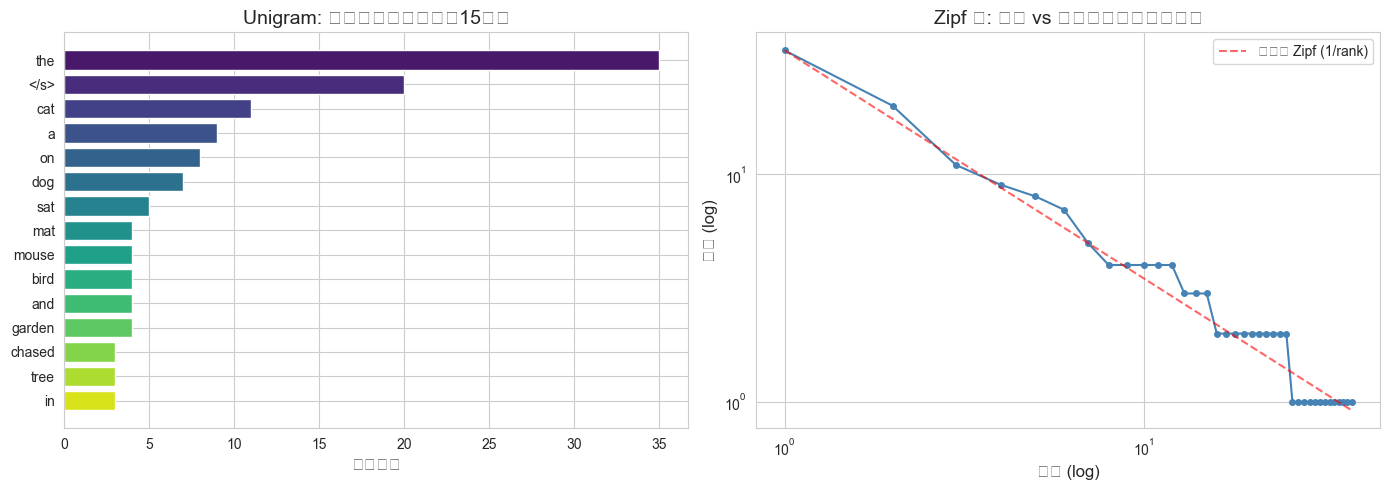


【考察】小規模コーパスでも、一部の単語（the, cat, on など）が
非常に高頻度で出現し、多くの単語は低頻度であるという Zipf 的傾向が見られます。


In [6]:
# ============================================================
# 可視化 1: 単語頻度の Zipf 則プロット
# ============================================================

# Zipf の法則: 単語の出現頻度は、頻度順位の逆数にほぼ比例する
# つまり、log-log プロットでほぼ直線になる

# 全単語を頻度順にソート
sorted_counts = sorted(unigram.word_counts.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左: 頻度分布（棒グラフ）---
top_words = unigram.word_counts.most_common(15)
words, counts = zip(*top_words)
colors = sns.color_palette('viridis', len(words))
axes[0].barh(range(len(words)), counts, color=colors)
axes[0].set_yticks(range(len(words)))
axes[0].set_yticklabels(words)
axes[0].invert_yaxis()  # 上位が上に来るように
axes[0].set_xlabel('出現回数')
axes[0].set_title('Unigram: 単語頻度分布（上位15語）')

# --- 右: Zipf 則（log-log プロット）---
axes[1].loglog(ranks, sorted_counts, 'o-', color='steelblue', markersize=4)
axes[1].set_xlabel('順位 (log)')
axes[1].set_ylabel('頻度 (log)')
axes[1].set_title('Zipf 則: 頻度 vs 順位（対数スケール）')

# 理想的な Zipf 則の直線を追加
# Zipf: f ∝ 1/rank → log(f) = -log(rank) + const
zipf_ideal = sorted_counts[0] / ranks
axes[1].loglog(ranks, zipf_ideal, '--', color='red', alpha=0.6, label='理想的 Zipf (1/rank)')
axes[1].legend()

plt.tight_layout()
plt.savefig('zipf_plot.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n【考察】小規模コーパスでも、一部の単語（the, cat, on など）が")
print("非常に高頻度で出現し、多くの単語は低頻度であるという Zipf 的傾向が見られます。")

---
# ============================================================
# セクション 4: Bigram モデル
# ============================================================

## 4.1 Bigram モデルとは

Bigram モデルは、直前の1単語のみに基づいて次の単語を予測します（1次マルコフ仮定）：

$$P(w_i | w_1, \ldots, w_{i-1}) \approx P(w_i | w_{i-1})$$

$$P(w_i | w_{i-1}) = \frac{\text{count}(w_{i-1}, w_i)}{\text{count}(w_{i-1})}$$

Unigram と異なり、**単語の並び順（文脈）** をある程度考慮できます。

In [7]:
# ============================================================
# セクション 4: Bigram モデルの実装
# ============================================================

class BigramModel:
    """Bigram 言語モデル
    
    直前の1単語を条件として次の単語の確率を推定するモデル。
    マルコフ仮定 (k=1) に基づく。
    """
    
    def __init__(self):
        # bigram カウント: bigram_counts[(w_{i-1}, w_i)] = count
        self.bigram_counts = Counter()
        # 文脈（直前の単語）のカウント: context_counts[w_{i-1}] = count
        self.context_counts = Counter()
        # 語彙
        self.vocab = set()
    
    def train(self, tokenized_sentences):
        """コーパスから bigram 確率を学習する
        
        Args:
            tokenized_sentences: トークン化された文のリスト
        """
        for tokens in tokenized_sentences:
            # 文頭・文末マーカーを付与（bigram なので <s> は1つ）
            marked = add_markers(tokens, n=2)
            # bigram をカウント
            for i in range(len(marked) - 1):
                context = marked[i]      # 直前の単語
                word = marked[i + 1]     # 現在の単語
                self.bigram_counts[(context, word)] += 1
                self.context_counts[context] += 1
                self.vocab.add(word)
                self.vocab.add(context)
        
        print(f"学習完了: 語彙={len(self.vocab)}, "
              f"ユニークbigram数={len(self.bigram_counts)}")
    
    def probability(self, word, context):
        """条件付き確率 P(word | context) を返す"""
        count_bigram = self.bigram_counts[(context, word)]
        count_context = self.context_counts[context]
        if count_context == 0:
            return 0.0
        return count_bigram / count_context
    
    def sentence_log_probability(self, tokens):
        """文全体の対数確率を計算する"""
        marked = add_markers(tokens, n=2)
        log_prob = 0.0
        for i in range(1, len(marked)):
            context = marked[i - 1]
            word = marked[i]
            p = self.probability(word, context)
            if p == 0:
                return float('-inf')  # ゼロ確率
            log_prob += math.log(p)
        return log_prob
    
    def sentence_probability_readable(self, tokens):
        """文の確率計算過程を表示する"""
        marked = add_markers(tokens, n=2)
        total_log = 0.0
        print(f"文: {' '.join(tokens)}")
        print(f"マーカー付き: {' '.join(marked)}")
        print("-" * 60)
        for i in range(1, len(marked)):
            context = marked[i - 1]
            word = marked[i]
            p = self.probability(word, context)
            log_p = math.log(p) if p > 0 else float('-inf')
            total_log += log_p
            print(f"  P({word:>12s} | {context:>8s}) = {p:.4f}  (log = {log_p:.4f})")
        print("-" * 60)
        print(f"  合計 log P = {total_log:.4f}")
        if total_log > float('-inf'):
            print(f"  P(文) = {math.exp(total_log):.2e}")
        return total_log
    
    def generate(self, max_length=20, start_token='<s>'):
        """Bigram モデルを使ってテキストを生成する
        
        Args:
            max_length: 生成する最大トークン数
            start_token: 開始トークン
        Returns:
            生成されたトークンリスト
        """
        current = start_token
        generated = []
        
        for _ in range(max_length):
            # 現在の文脈に対する次の単語の確率分布を取得
            candidates = []
            probs = []
            for (ctx, w), count in self.bigram_counts.items():
                if ctx == current:
                    candidates.append(w)
                    probs.append(self.probability(w, current))
            
            if not candidates:
                break
            
            # 確率に基づいてサンプリング
            probs = np.array(probs)
            probs = probs / probs.sum()  # 正規化
            next_word = np.random.choice(candidates, p=probs)
            
            if next_word == '</s>':
                break
            
            generated.append(next_word)
            current = next_word
        
        return generated

# --- モデルの学習 ---
bigram = BigramModel()
bigram.train(train_tokens_list)

学習完了: 語彙=39, ユニークbigram数=83


In [8]:
# --- Bigram でテスト文の確率を計算 ---
print("=" * 60)
print("テスト文の確率計算（Bigram モデル）")
print("=" * 60)
for sent in test_corpus:
    tokens = tokenize(sent)
    bigram.sentence_probability_readable(tokens)
    print()

テスト文の確率計算（Bigram モデル）
文: the cat sat on the rug
マーカー付き: <s> the cat sat on the rug </s>
------------------------------------------------------------
  P(         the |      <s>) = 0.7500  (log = -0.2877)
  P(         cat |      the) = 0.2571  (log = -1.3581)
  P(         sat |      cat) = 0.2727  (log = -1.2993)
  P(          on |      sat) = 0.8000  (log = -0.2231)
  P(         the |       on) = 0.8750  (log = -0.1335)
  P(         rug |      the) = 0.0571  (log = -2.8622)
  P(        </s> |      rug) = 0.5000  (log = -0.6931)
------------------------------------------------------------
  合計 log P = -6.8571
  P(文) = 1.05e-03

文: a dog chased the bird
マーカー付き: <s> a dog chased the bird </s>
------------------------------------------------------------
  P(           a |      <s>) = 0.2500  (log = -1.3863)
  P(         dog |        a) = 0.1111  (log = -2.1972)
  P(      chased |      dog) = 0.2857  (log = -1.2528)
  P(         the |   chased) = 0.6667  (log = -0.4055)
  P(        bird |  

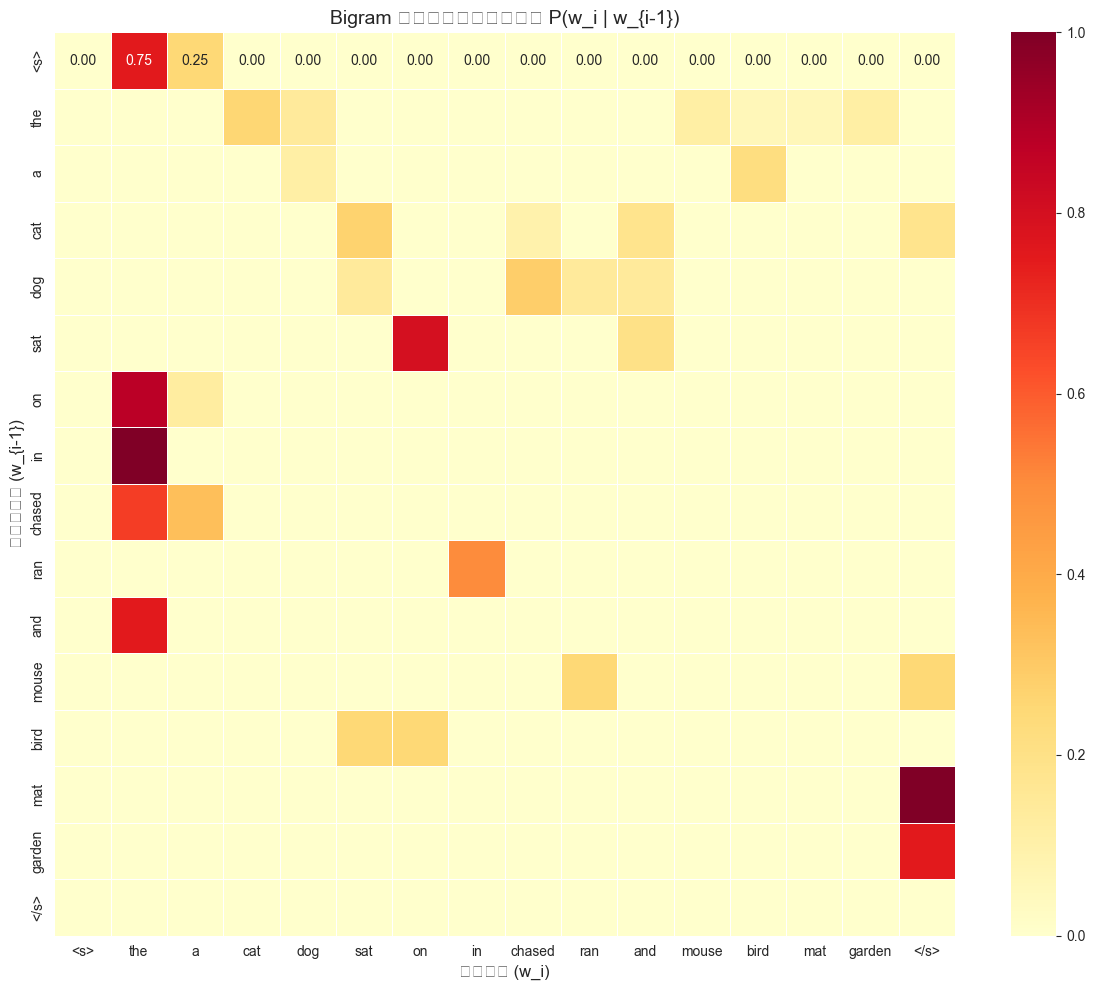


【考察】
- <s>（文頭）の後は 'the' や 'a' が高確率（冠詞から始まる文が多い）
- 'on' の後は 'the' が高確率（'on the mat', 'on the tree' など）
- 'sat' の後は 'on' や 'and' が高確率


In [9]:
# ============================================================
# 可視化 2: Bigram 遷移確率ヒートマップ
# ============================================================

# 主要な単語に絞って遷移確率行列を可視化する
# （全語彙だと大きすぎるため、頻出語彙を選択）

# 表示する単語を選択（頻出語 + マーカー）
display_words = ['<s>', 'the', 'a', 'cat', 'dog', 'sat', 'on', 'in',
                 'chased', 'ran', 'and', 'mouse', 'bird', 'mat', 'garden', '</s>']

# 遷移確率行列を構築
transition_matrix = np.zeros((len(display_words), len(display_words)))

for i, ctx in enumerate(display_words):
    for j, word in enumerate(display_words):
        transition_matrix[i, j] = bigram.probability(word, ctx)

# ヒートマップの描画
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    transition_matrix,
    xticklabels=display_words,
    yticklabels=display_words,
    annot=True,       # セル内に数値を表示
    fmt='.2f',        # 小数2桁
    cmap='YlOrRd',    # カラーマップ
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('次の単語 (w_i)')
ax.set_ylabel('直前の単語 (w_{i-1})')
ax.set_title('Bigram 遷移確率ヒートマップ P(w_i | w_{i-1})')
plt.tight_layout()
plt.savefig('bigram_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n【考察】")
print("- <s>（文頭）の後は 'the' や 'a' が高確率（冠詞から始まる文が多い）")
print("- 'on' の後は 'the' が高確率（'on the mat', 'on the tree' など）")
print("- 'sat' の後は 'on' や 'and' が高確率")

In [10]:
# ============================================================
# Bigram テキスト生成デモ
# ============================================================

print("=" * 60)
print("Bigram モデルによるテキスト生成（5文）")
print("=" * 60)

# シードを固定して再現性を確保
np.random.seed(42)

for i in range(5):
    generated = bigram.generate(max_length=15)
    print(f"  生成文 {i+1}: {' '.join(generated)}")

print("\n【考察】")
print("Bigram モデルは直前の1単語しか見ないため、")
print("局所的には自然でも、文全体としては不自然な文が生成されることがあります。")

Bigram モデルによるテキスト生成（5文）
  生成文 1: the fire
  生成文 2: the cat sat on the mouse hid under the table
  生成文 3: the cat chased the dog chased the cat chased the dog ran under the mouse
  生成文 4: the mouse
  生成文 5: the fire

【考察】
Bigram モデルは直前の1単語しか見ないため、
局所的には自然でも、文全体としては不自然な文が生成されることがあります。


---
# ============================================================
# セクション 5: Trigram モデル
# ============================================================

## 5.1 Trigram モデルとは

Trigram モデルは直前の **2単語** を文脈として使います（2次マルコフ仮定）：

$$P(w_i | w_1, \ldots, w_{i-1}) \approx P(w_i | w_{i-2}, w_{i-1})$$

$$P(w_i | w_{i-2}, w_{i-1}) = \frac{\text{count}(w_{i-2}, w_{i-1}, w_i)}{\text{count}(w_{i-2}, w_{i-1})}$$

Bigram より長い文脈を捉えられますが、**データスパース性** の問題が深刻になります。

In [11]:
# ============================================================
# セクション 5: Trigram モデルの実装
# ============================================================

class TrigramModel:
    """Trigram 言語モデル
    
    直前の2単語を条件として次の単語の確率を推定するモデル。
    マルコフ仮定 (k=2) に基づく。
    """
    
    def __init__(self):
        # trigram カウント: trigram_counts[(w_{i-2}, w_{i-1}, w_i)] = count
        self.trigram_counts = Counter()
        # bigram 文脈のカウント: context_counts[(w_{i-2}, w_{i-1})] = count
        self.context_counts = Counter()
        # 語彙
        self.vocab = set()
    
    def train(self, tokenized_sentences):
        """コーパスから trigram 確率を学習する"""
        for tokens in tokenized_sentences:
            # Trigram なので文頭マーカーを2つ付ける
            marked = add_markers(tokens, n=3)
            # trigram をカウント
            for i in range(len(marked) - 2):
                ctx1 = marked[i]      # 2つ前の単語
                ctx2 = marked[i + 1]  # 1つ前の単語
                word = marked[i + 2]  # 現在の単語
                self.trigram_counts[(ctx1, ctx2, word)] += 1
                self.context_counts[(ctx1, ctx2)] += 1
                self.vocab.add(word)
        
        print(f"学習完了: 語彙={len(self.vocab)}, "
              f"ユニークtrigram数={len(self.trigram_counts)}")
    
    def probability(self, word, context1, context2):
        """条件付き確率 P(word | context1, context2) を返す"""
        count_trigram = self.trigram_counts[(context1, context2, word)]
        count_context = self.context_counts[(context1, context2)]
        if count_context == 0:
            return 0.0
        return count_trigram / count_context
    
    def sentence_log_probability(self, tokens):
        """文全体の対数確率を計算する"""
        marked = add_markers(tokens, n=3)
        log_prob = 0.0
        for i in range(2, len(marked)):
            ctx1 = marked[i - 2]
            ctx2 = marked[i - 1]
            word = marked[i]
            p = self.probability(word, ctx1, ctx2)
            if p == 0:
                return float('-inf')  # ゼロ確率
            log_prob += math.log(p)
        return log_prob

# --- モデルの学習 ---
trigram = TrigramModel()
trigram.train(train_tokens_list)

学習完了: 語彙=38, ユニークtrigram数=112


In [12]:
# ============================================================
# Bigram vs Trigram: スパース性の比較
# ============================================================

print("=" * 60)
print("Bigram vs Trigram: スパース性の比較")
print("=" * 60)

# Bigram: 可能な組み合わせ数 vs 実際に観測された数
vocab_size = len(bigram.vocab)
possible_bigrams = vocab_size * vocab_size
observed_bigrams = len(bigram.bigram_counts)
bigram_coverage = observed_bigrams / possible_bigrams * 100

print(f"\n【Bigram モデル】")
print(f"  語彙サイズ: {vocab_size}")
print(f"  可能な bigram 数: {vocab_size} x {vocab_size} = {possible_bigrams:,}")
print(f"  観測された bigram 数: {observed_bigrams}")
print(f"  カバー率: {bigram_coverage:.2f}%")
print(f"  ゼロ確率の bigram: {possible_bigrams - observed_bigrams:,} ({100 - bigram_coverage:.2f}%)")

# Trigram: 可能な組み合わせ数 vs 実際に観測された数
possible_trigrams = vocab_size ** 3
observed_trigrams = len(trigram.trigram_counts)
trigram_coverage = observed_trigrams / possible_trigrams * 100

print(f"\n【Trigram モデル】")
print(f"  可能な trigram 数: {vocab_size}^3 = {possible_trigrams:,}")
print(f"  観測された trigram 数: {observed_trigrams}")
print(f"  カバー率: {trigram_coverage:.4f}%")
print(f"  ゼロ確率の trigram: {possible_trigrams - observed_trigrams:,} ({100 - trigram_coverage:.4f}%)")

print(f"\n【結論】")
print(f"N を増やすと文脈は豊富になるが、スパース性が指数的に悪化します。")
print(f"Trigram のカバー率は Bigram の {bigram_coverage / trigram_coverage:.0f} 分の1程度です。")

Bigram vs Trigram: スパース性の比較

【Bigram モデル】
  語彙サイズ: 39
  可能な bigram 数: 39 x 39 = 1,521
  観測された bigram 数: 83
  カバー率: 5.46%
  ゼロ確率の bigram: 1,438 (94.54%)

【Trigram モデル】
  可能な trigram 数: 39^3 = 59,319
  観測された trigram 数: 112
  カバー率: 0.1888%
  ゼロ確率の trigram: 59,207 (99.8112%)

【結論】
N を増やすと文脈は豊富になるが、スパース性が指数的に悪化します。
Trigram のカバー率は Bigram の 29 分の1程度です。


---
# ============================================================
# セクション 6: スムージング手法
# ============================================================

## 6.1 なぜスムージングが必要か？

N-gram モデルの大きな問題は **ゼロ確率問題** です。

- 学習コーパスに出現しない N-gram の確率が 0 になる
- 文中に1つでもゼロ確率の N-gram があると、文全体の確率が 0 になる
- パープレキシティが無限大になってしまう

これを解決するのが **スムージング（平滑化）** です。

In [13]:
# ============================================================
# セクション 6: スムージング手法の実装
# ============================================================

# --- 6.1 ラプラス（加算）スムージング ---

class BigramModelLaplace:
    """ラプラススムージング付き Bigram モデル
    
    すべての bigram カウントに定数 k を加算することで、
    ゼロ確率の問題を回避する。k=1 の場合が「ラプラススムージング」。
    
    P_laplace(w_i | w_{i-1}) = (count(w_{i-1}, w_i) + k) / (count(w_{i-1}) + k * V)
    ここで V は語彙サイズ
    """
    
    def __init__(self, k=1.0):
        self.k = k  # スムージングパラメータ
        self.bigram_counts = Counter()
        self.context_counts = Counter()
        self.vocab = set()
    
    def train(self, tokenized_sentences):
        """コーパスから学習する"""
        for tokens in tokenized_sentences:
            marked = add_markers(tokens, n=2)
            for i in range(len(marked) - 1):
                context = marked[i]
                word = marked[i + 1]
                self.bigram_counts[(context, word)] += 1
                self.context_counts[context] += 1
                self.vocab.add(word)
                self.vocab.add(context)
        
        print(f"学習完了（ラプラス k={self.k}）: 語彙={len(self.vocab)}")
    
    def probability(self, word, context):
        """ラプラススムージング付きの条件付き確率"""
        count_bigram = self.bigram_counts[(context, word)]
        count_context = self.context_counts[context]
        V = len(self.vocab)
        # ラプラススムージングの式
        return (count_bigram + self.k) / (count_context + self.k * V)
    
    def sentence_log_probability(self, tokens):
        """文全体の対数確率を計算する"""
        marked = add_markers(tokens, n=2)
        log_prob = 0.0
        for i in range(1, len(marked)):
            context = marked[i - 1]
            word = marked[i]
            p = self.probability(word, context)
            if p == 0:
                return float('-inf')
            log_prob += math.log(p)
        return log_prob

# --- モデルの学習 ---
bigram_laplace = BigramModelLaplace(k=1.0)
bigram_laplace.train(train_tokens_list)

学習完了（ラプラス k=1.0）: 語彙=39


In [14]:
# --- 6.2 補間法（Interpolation）---

class BigramModelInterpolation:
    """補間法（線形補間）付き Bigram モデル
    
    Unigram と Bigram の確率を重み付き平均で組み合わせる：
    P_interp(w_i | w_{i-1}) = λ₂ * P_bigram(w_i | w_{i-1}) + λ₁ * P_unigram(w_i)
    
    ここで λ₁ + λ₂ = 1
    """
    
    def __init__(self, lambda_bigram=0.7, lambda_unigram=0.3):
        # 補間の重み
        self.lambda_bigram = lambda_bigram
        self.lambda_unigram = lambda_unigram
        # Bigram 部分
        self.bigram_counts = Counter()
        self.context_counts = Counter()
        # Unigram 部分
        self.unigram_counts = Counter()
        self.total_count = 0
        self.vocab = set()
    
    def train(self, tokenized_sentences):
        """コーパスから学習する"""
        for tokens in tokenized_sentences:
            marked = add_markers(tokens, n=2)
            # bigram カウント
            for i in range(len(marked) - 1):
                context = marked[i]
                word = marked[i + 1]
                self.bigram_counts[(context, word)] += 1
                self.context_counts[context] += 1
                self.vocab.add(word)
                self.vocab.add(context)
            # unigram カウント
            for token in marked:
                self.unigram_counts[token] += 1
                self.total_count += 1
        
        print(f"学習完了（補間法 λ_bi={self.lambda_bigram}, λ_uni={self.lambda_unigram}）")
    
    def probability(self, word, context):
        """補間法による条件付き確率"""
        # Bigram 確率
        count_bigram = self.bigram_counts[(context, word)]
        count_context = self.context_counts[context]
        p_bigram = count_bigram / count_context if count_context > 0 else 0.0
        
        # Unigram 確率
        p_unigram = self.unigram_counts[word] / self.total_count if self.total_count > 0 else 0.0
        
        # 線形補間
        return self.lambda_bigram * p_bigram + self.lambda_unigram * p_unigram
    
    def sentence_log_probability(self, tokens):
        """文全体の対数確率を計算する"""
        marked = add_markers(tokens, n=2)
        log_prob = 0.0
        for i in range(1, len(marked)):
            context = marked[i - 1]
            word = marked[i]
            p = self.probability(word, context)
            if p == 0:
                return float('-inf')
            log_prob += math.log(p)
        return log_prob

# --- モデルの学習 ---
bigram_interp = BigramModelInterpolation(lambda_bigram=0.7, lambda_unigram=0.3)
bigram_interp.train(train_tokens_list)

学習完了（補間法 λ_bi=0.7, λ_uni=0.3）


### 6.3 Kneser-Ney スムージング（概念的説明）

**Kneser-Ney スムージング** は最も効果的なスムージング手法の一つです。

#### 核心的アイデア

通常の Bigram バックオフでは、未知の bigram に対して unigram 確率を使います。
しかし、単純な unigram 確率には問題があります。

**例**: 「San Francisco」というフレーズを考えます。
- 「Francisco」は unigram としては高頻度（San Francisco がたくさんある）
- しかし「Francisco」が出現する **文脈の種類** は「San」のみ
- 新しい文脈で「Francisco」が出現する確率は低いはず

#### Kneser-Ney の解決策

バックオフ先として、単語の出現頻度ではなく **continuation probability**（その単語が新しい文脈に出現する確率）を使用：

$$P_{\text{continuation}}(w) = \frac{|\{v : \text{count}(v, w) > 0\}|}{\sum_{w'} |\{v : \text{count}(v, w') > 0\}|}$$

さらに、**絶対割引（absolute discounting）** を組み合わせます：
- 各 N-gram のカウントから固定値 $d$（通常 0.75）を引く
- 引いた分の確率質量をバックオフ分布に再配分

> **注**: 完全な実装は複雑なため、ここでは概念の理解に留めます。実用には NLTK や KenLM などのライブラリを使用してください。

In [15]:
# ============================================================
# スムージング手法の比較実験
# ============================================================

# 未知の bigram を含むテスト文
test_sentences_smoothing = [
    "the cat sat on the mat",         # コーパスに存在する文
    "the cat sat on the rug",         # 部分的に新しい組み合わせ
    "a bird chased the dog",          # 新しい組み合わせが多い
    "the flower grew in the garden",  # 未知語（flower, grew）を含む
]

print("=" * 70)
print("スムージング手法の比較（文の対数確率）")
print("=" * 70)
print(f"{'文':<40s} {'Bigram':>10s} {'Laplace':>10s} {'補間法':>10s}")
print("-" * 70)

results = []
for sent in test_sentences_smoothing:
    tokens = tokenize(sent)
    # 各モデルで対数確率を計算
    lp_bigram = bigram.sentence_log_probability(tokens)
    lp_laplace = bigram_laplace.sentence_log_probability(tokens)
    lp_interp = bigram_interp.sentence_log_probability(tokens)
    
    # 表示用にフォーマット
    lp_b_str = f"{lp_bigram:.2f}" if lp_bigram > float('-inf') else "-inf"
    lp_l_str = f"{lp_laplace:.2f}" if lp_laplace > float('-inf') else "-inf"
    lp_i_str = f"{lp_interp:.2f}" if lp_interp > float('-inf') else "-inf"
    
    print(f"{sent:<40s} {lp_b_str:>10s} {lp_l_str:>10s} {lp_i_str:>10s}")
    results.append((sent, lp_bigram, lp_laplace, lp_interp))

print("\n【考察】")
print("- スムージングなしの Bigram は未知の組み合わせで -inf（確率ゼロ）になる")
print("- ラプラススムージングと補間法はゼロ確率を回避できる")
print("- ただし、ラプラスは確率質量を均等に配分するため、精度が低い場合がある")

スムージング手法の比較（文の対数確率）
文                                            Bigram    Laplace        補間法
----------------------------------------------------------------------
the cat sat on the mat                        -6.16     -15.13      -8.09
the cat sat on the rug                        -6.86     -16.00      -8.81
a bird chased the dog                          -inf     -17.80     -14.98
the flower grew in the garden                  -inf     -20.36       -inf

【考察】
- スムージングなしの Bigram は未知の組み合わせで -inf（確率ゼロ）になる
- ラプラススムージングと補間法はゼロ確率を回避できる
- ただし、ラプラスは確率質量を均等に配分するため、精度が低い場合がある


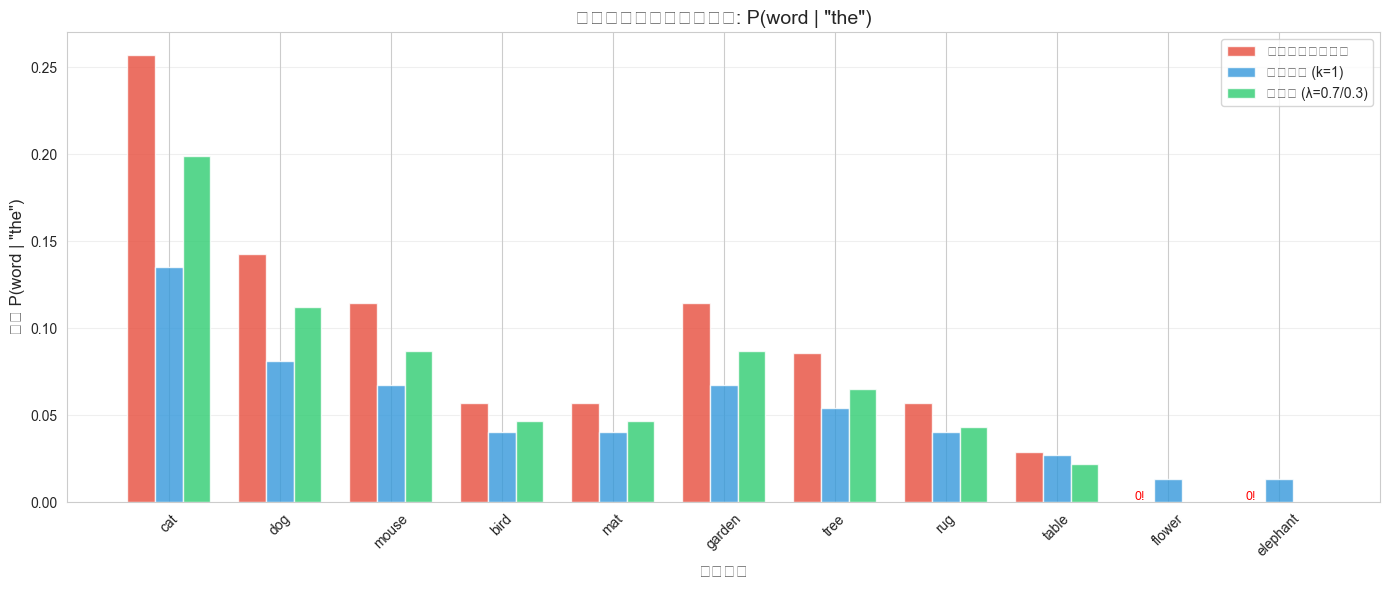

【ポイント】
- 赤い '0!' マークがスムージングなしでゼロ確率になる箇所
- ラプラス法は全単語に均一に確率を配分する（やや平坦になる）
- 補間法は元の Bigram 分布の形状を保ちつつ、ゼロを回避する


In [16]:
# ============================================================
# 可視化 3: スムージング効果の比較
# ============================================================

# 'the' の後に来る単語の確率分布をスムージング手法で比較
context_word = 'the'

# 表示する次の単語（コーパス内の頻出語 + 未知語）
next_words = ['cat', 'dog', 'mouse', 'bird', 'mat', 'garden',
              'tree', 'rug', 'table', 'flower', 'elephant']

# 各モデルの確率を計算
probs_no_smooth = [bigram.probability(w, context_word) for w in next_words]
probs_laplace = [bigram_laplace.probability(w, context_word) for w in next_words]
probs_interp = [bigram_interp.probability(w, context_word) for w in next_words]

# 棒グラフで比較
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(next_words))
width = 0.25

bars1 = ax.bar(x - width, probs_no_smooth, width, label='スムージングなし', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x, probs_laplace, width, label='ラプラス (k=1)', color='#3498db', alpha=0.8)
bars3 = ax.bar(x + width, probs_interp, width, label='補間法 (λ=0.7/0.3)', color='#2ecc71', alpha=0.8)

ax.set_xlabel('次の単語')
ax.set_ylabel('確率 P(word | "the")')
ax.set_title(f'スムージング手法の比較: P(word | "{context_word}")')
ax.set_xticks(x)
ax.set_xticklabels(next_words, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ゼロ確率の箇所にマーカーを追加
for i, p in enumerate(probs_no_smooth):
    if p == 0:
        ax.annotate('0!', xy=(i - width, 0.001), ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('smoothing_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("【ポイント】")
print("- 赤い '0!' マークがスムージングなしでゼロ確率になる箇所")
print("- ラプラス法は全単語に均一に確率を配分する（やや平坦になる）")
print("- 補間法は元の Bigram 分布の形状を保ちつつ、ゼロを回避する")

---
# ============================================================
# セクション 7: パープレキシティ
# ============================================================

## 7.1 パープレキシティとは？

**パープレキシティ（Perplexity, PPL）** は言語モデルの評価指標です。

### 数式定義

$$\text{PPL} = \exp\left( -\frac{1}{N} \sum_{i=1}^{N} \log P(w_i | \text{context}) \right)$$

ここで $N$ はテストデータの総トークン数です。

### 直感的理解

**「次の単語の平均的な選択肢の数」** と解釈できます。

- PPL = 10 → モデルは毎回10個の単語から1つを選ぶのと同じ不確実さ
- PPL = 100 → 毎回100個の候補がある状態（モデルの予測力が低い）
- PPL = 1 → 完全に予測可能（理想的だが非現実的）

**PPL が低いほど良いモデル** です。

### エントロピーとの関係

パープレキシティはクロスエントロピー $H$ の指数です：
$$\text{PPL} = 2^{H} = \exp(H_{\text{nat}})$$

ここで $H_{\text{nat}} = -\frac{1}{N} \sum_{i=1}^{N} \ln P(w_i | \text{context})$（自然対数版）

In [17]:
# ============================================================
# セクション 7: パープレキシティの計算
# ============================================================

def compute_perplexity_unigram(model, tokenized_sentences):
    """Unigram モデルのパープレキシティを計算する
    
    PPL = exp(-1/N * Σ log P(w_i))
    
    Args:
        model: UnigramModel インスタンス
        tokenized_sentences: テスト文のリスト
    Returns:
        パープレキシティ値
    """
    total_log_prob = 0.0
    total_tokens = 0
    
    for tokens in tokenized_sentences:
        marked = tokens + ['</s>']
        for w in marked:
            p = model.probability(w)
            if p == 0:
                return float('inf')  # ゼロ確率 → 無限大
            total_log_prob += math.log(p)
            total_tokens += 1
    
    # PPL = exp(-1/N * Σ log P)
    avg_log_prob = total_log_prob / total_tokens
    perplexity = math.exp(-avg_log_prob)
    return perplexity


def compute_perplexity_bigram(model, tokenized_sentences):
    """Bigram モデルのパープレキシティを計算する
    
    PPL = exp(-1/N * Σ log P(w_i | w_{i-1}))
    """
    total_log_prob = 0.0
    total_tokens = 0
    
    for tokens in tokenized_sentences:
        marked = add_markers(tokens, n=2)
        for i in range(1, len(marked)):
            context = marked[i - 1]
            word = marked[i]
            p = model.probability(word, context)
            if p == 0:
                return float('inf')  # ゼロ確率 → 無限大
            total_log_prob += math.log(p)
            total_tokens += 1
    
    avg_log_prob = total_log_prob / total_tokens
    perplexity = math.exp(-avg_log_prob)
    return perplexity


def compute_perplexity_trigram(model, tokenized_sentences):
    """Trigram モデルのパープレキシティを計算する
    
    PPL = exp(-1/N * Σ log P(w_i | w_{i-2}, w_{i-1}))
    """
    total_log_prob = 0.0
    total_tokens = 0
    
    for tokens in tokenized_sentences:
        marked = add_markers(tokens, n=3)
        for i in range(2, len(marked)):
            ctx1 = marked[i - 2]
            ctx2 = marked[i - 1]
            word = marked[i]
            p = model.probability(word, ctx1, ctx2)
            if p == 0:
                return float('inf')
            total_log_prob += math.log(p)
            total_tokens += 1
    
    avg_log_prob = total_log_prob / total_tokens
    perplexity = math.exp(-avg_log_prob)
    return perplexity


# --- 学習データでのパープレキシティ ---
print("=" * 60)
print("各モデルのパープレキシティ（学習データ上）")
print("=" * 60)

ppl_unigram_train = compute_perplexity_unigram(unigram, train_tokens_list)
ppl_bigram_train = compute_perplexity_bigram(bigram, train_tokens_list)
ppl_trigram_train = compute_perplexity_trigram(trigram, train_tokens_list)

print(f"  Unigram:  PPL = {ppl_unigram_train:.2f}")
print(f"  Bigram:   PPL = {ppl_bigram_train:.2f}")
print(f"  Trigram:  PPL = {ppl_trigram_train:.2f}")

# --- テストデータでのパープレキシティ ---
test_tokens_list = [tokenize(s) for s in test_corpus]

print(f"\n{'=' * 60}")
print("各モデルのパープレキシティ（テストデータ上）")
print("=" * 60)

ppl_unigram_test = compute_perplexity_unigram(unigram, test_tokens_list)
ppl_bigram_test = compute_perplexity_bigram(bigram, test_tokens_list)
ppl_trigram_test = compute_perplexity_trigram(trigram, test_tokens_list)

print(f"  Unigram:  PPL = {ppl_unigram_test:.2f}")
print(f"  Bigram:   PPL = {ppl_bigram_test:.2f}")
print(f"  Trigram:  PPL = {ppl_trigram_test if ppl_trigram_test != float('inf') else 'inf (ゼロ確率発生)'}")

# スムージング付きモデルのテストデータ PPL
ppl_laplace_test = compute_perplexity_bigram(bigram_laplace, test_tokens_list)
ppl_interp_test = compute_perplexity_bigram(bigram_interp, test_tokens_list)

print(f"\n  Bigram+Laplace:    PPL = {ppl_laplace_test:.2f}")
print(f"  Bigram+補間法:     PPL = {ppl_interp_test:.2f}")

print("\n【考察】")
print("- 学習データ上では N が大きいほど PPL が低い（過学習の傾向）")
print("- テストデータ上では Trigram がゼロ確率に陥りやすい")
print("- スムージングにより PPL が有限値になり、比較可能になる")

各モデルのパープレキシティ（学習データ上）
  Unigram:  PPL = 20.41
  Bigram:   PPL = 2.94
  Trigram:  PPL = 1.95

各モデルのパープレキシティ（テストデータ上）
  Unigram:  PPL = 18.34
  Bigram:   PPL = inf
  Trigram:  PPL = inf (ゼロ確率発生)

  Bigram+Laplace:    PPL = 14.23
  Bigram+補間法:     PPL = 4.88

【考察】
- 学習データ上では N が大きいほど PPL が低い（過学習の傾向）
- テストデータ上では Trigram がゼロ確率に陥りやすい
- スムージングにより PPL が有限値になり、比較可能になる


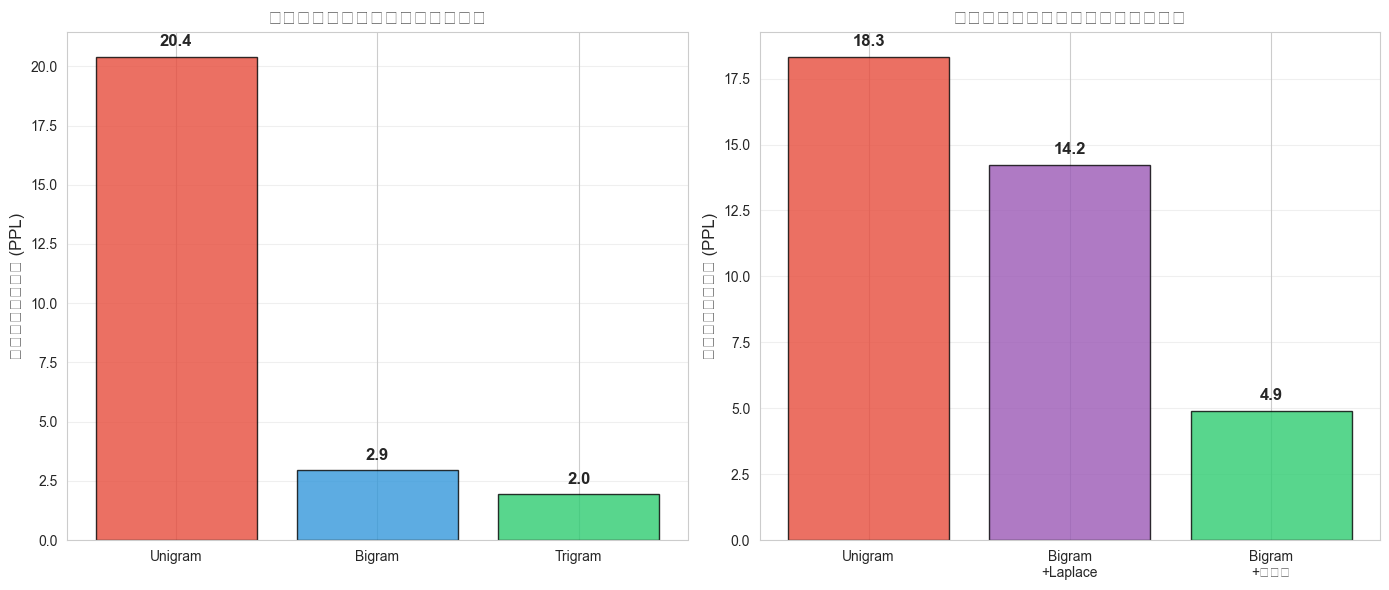

【解釈のポイント】
- PPL が低い = モデルの予測力が高い（次の単語をよく予測できている）
- 学習データでは N が大きいほど PPL は下がるが、テストデータでは必ずしもそうではない
- スムージングの効果: ゼロ確率を回避し、汎化性能を向上させる


In [18]:
# ============================================================
# 可視化 4: N-gram 次数とパープレキシティの関係
# ============================================================

# 学習データとテストデータの PPL を比較
# Trigram のテストデータが inf の場合はスムージング版で代用

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 左: 学習データ上の PPL ---
models_train = ['Unigram', 'Bigram', 'Trigram']
ppl_train_values = [ppl_unigram_train, ppl_bigram_train, ppl_trigram_train]
colors_train = ['#e74c3c', '#3498db', '#2ecc71']

bars = axes[0].bar(models_train, ppl_train_values, color=colors_train, alpha=0.8, edgecolor='black')
axes[0].set_ylabel('パープレキシティ (PPL)')
axes[0].set_title('学習データ上のパープレキシティ')
axes[0].grid(axis='y', alpha=0.3)

# 値をバーの上に表示
for bar, val in zip(bars, ppl_train_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- 右: テストデータ上の PPL（スムージング手法別）---
models_test = ['Unigram', 'Bigram', 'Bigram\n+Laplace', 'Bigram\n+補間法']
ppl_test_values = [ppl_unigram_test, ppl_bigram_test, ppl_laplace_test, ppl_interp_test]
colors_test = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71']

# inf の値は除外してプロットする
ppl_test_plot = []
labels_plot = []
colors_plot = []
for m, p, c in zip(models_test, ppl_test_values, colors_test):
    if p != float('inf'):
        ppl_test_plot.append(p)
        labels_plot.append(m)
        colors_plot.append(c)

bars2 = axes[1].bar(labels_plot, ppl_test_plot, color=colors_plot, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('パープレキシティ (PPL)')
axes[1].set_title('テストデータ上のパープレキシティ')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, ppl_test_plot):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('perplexity_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("【解釈のポイント】")
print("- PPL が低い = モデルの予測力が高い（次の単語をよく予測できている）")
print("- 学習データでは N が大きいほど PPL は下がるが、テストデータでは必ずしもそうではない")
print("- スムージングの効果: ゼロ確率を回避し、汎化性能を向上させる")

In [19]:
# ============================================================
# パープレキシティの直感的理解: インタラクティブ例
# ============================================================

print("=" * 60)
print("パープレキシティの直感的理解")
print("=" * 60)

# 例1: 確定的な場合（PPL = 1）
print("\n【例1: PPL = 1 の場合】")
print("  毎回確率 1.0 で次の単語を予測できる → PPL = exp(0) = 1")
print("  つまり『選択肢が1つしかない（完全に予測可能）』")

# 例2: 一様分布の場合
print("\n【例2: 語彙 V=100 で一様分布の場合】")
V = 100
ppl_uniform = V
print(f"  毎回 P(w) = 1/{V} → PPL = exp(-log(1/{V})) = {ppl_uniform}")
print(f"  つまり『毎回 {V} 個の候補から当てずっぽうに選ぶのと同じ』")

# 例3: 実際のモデルの場合
print(f"\n【例3: 我々の Bigram モデルの場合】")
print(f"  テストデータ上の PPL = {ppl_bigram_test:.2f}")
print(f"  つまり、平均的に約 {ppl_bigram_test:.0f} 個の候補から選んでいるのと同じ不確実さ")

# PPL と語彙サイズの関係を可視化
print("\n【参考: 実世界の言語モデルの PPL】")
print("  +-----------------------+----------+")
print("  | モデル                | PPL      |")
print("  +-----------------------+----------+")
print("  | 一様分布 (V=10000)    | 10000    |")
print("  | Unigram               | 100-1000 |")
print("  | Bigram                | 50-200   |")
print("  | Trigram + KN           | 50-100   |")
print("  | LSTM LM               | 30-80    |")
print("  | GPT-2                 | 15-30    |")
print("  | GPT-3 / GPT-4         | < 15     |")
print("  +-----------------------+----------+")

パープレキシティの直感的理解

【例1: PPL = 1 の場合】
  毎回確率 1.0 で次の単語を予測できる → PPL = exp(0) = 1
  つまり『選択肢が1つしかない（完全に予測可能）』

【例2: 語彙 V=100 で一様分布の場合】
  毎回 P(w) = 1/100 → PPL = exp(-log(1/100)) = 100
  つまり『毎回 100 個の候補から当てずっぽうに選ぶのと同じ』

【例3: 我々の Bigram モデルの場合】
  テストデータ上の PPL = inf
  つまり、平均的に約 inf 個の候補から選んでいるのと同じ不確実さ

【参考: 実世界の言語モデルの PPL】
  +-----------------------+----------+
  | モデル                | PPL      |
  +-----------------------+----------+
  | 一様分布 (V=10000)    | 10000    |
  | Unigram               | 100-1000 |
  | Bigram                | 50-200   |
  | Trigram + KN           | 50-100   |
  | LSTM LM               | 30-80    |
  | GPT-2                 | 15-30    |
  | GPT-3 / GPT-4         | < 15     |
  +-----------------------+----------+


---
# ============================================================
# セクション 8: N-gram モデルの限界と次への展望
# ============================================================

## 8.1 N-gram モデルの限界

### (1) 長距離依存性の欠如

N-gram モデルは直前の $N-1$ 単語しか参照できません。

**例**: 「**The students** who passed the difficult final exam **were** happy.」
- 「were」は「students」（主語が複数形）に依存するが、Trigram では届かない
- 長い修飾節や関係節を跨ぐ依存関係を捉えられない

### (2) データスパース性

- N を大きくすると文脈は豊富になるが、可能な N-gram の数は $V^N$ で爆発
- 十分なデータがないと信頼できる確率推定ができない
- 大規模コーパスでも、5-gram を超えるとスパース性が深刻

### (3) 語彙外（OOV）問題

- 学習コーパスに含まれない単語には対応できない
- 新語、固有名詞、専門用語などが問題になる
- `<UNK>` トークンで対処するが、情報が失われる

### (4) 一般化能力の限界

- 「猫がマットの上に座った」と「犬がマットの上に座った」を別々にカウント
- 「猫」と「犬」が類似した文脈に出現するという知識を共有できない
- → **分散表現（Embeddings）** の必要性（Notebook 150-157 で学習済み）

## 8.2 ニューラル言語モデルへの動機

| N-gram の限界 | ニューラル LM の解決策 |
|---------------|------------------------|
| 固定長の文脈 | RNN / Transformer で可変長の文脈を処理 |
| スパース性 | 連続的な embedding 空間で一般化 |
| 類似語の共有不可 | embedding の類似性で知識を共有 |
| 語彙外問題 | サブワード tokenization (BPE) で対処 |

次のノートブックでは：
- **Notebook 162**: RNN 言語モデル（LSTM/GRU ベース）
- **Notebook 164**: Transformer 言語モデル

へと進み、これらの限界を克服する手法を学びます。

In [20]:
# ============================================================
# セクション 8: 長距離依存性の限界を実験で確認
# ============================================================

# 長距離依存性の例: 主語と動詞の一致
# N-gram では文脈窓の外にある情報を捉えられないことを実証する

print("=" * 60)
print("N-gram モデルの限界: 長距離依存性")
print("=" * 60)

# 長い文脈を持つ例
long_sentences = [
    # 主語と動詞が近い場合（Bigram で十分）
    "the cat sat on the mat",
    # 主語と動詞の間に修飾句がある場合
    "the cat that chased the mouse sat on the mat",
    # さらに長い修飾
    "the cat that chased the mouse in the garden sat on the big mat",
]

print("\n【文の長さと確率の関係】")
for sent in long_sentences:
    tokens = tokenize(sent)
    lp_bi = bigram.sentence_log_probability(tokens)
    lp_lap = bigram_laplace.sentence_log_probability(tokens)
    n_tokens = len(tokens)
    
    bi_str = f"{lp_bi:.2f}" if lp_bi > float('-inf') else "-inf"
    lap_str = f"{lp_lap:.2f}"
    
    print(f"\n  文 ({n_tokens}語): {sent}")
    print(f"    Bigram log P     = {bi_str}")
    print(f"    Bigram+Lap log P = {lap_str}")

print("\n【考察】")
print("- 修飾句が長くなるほど、N-gram では主語の情報が失われる")
print("- Bigram は常に直前の1語しか参照しないため、")
print("  'garden sat' のような bigram の確率に依存してしまう")
print("- この限界がニューラル言語モデル（RNN, Transformer）の動機となる")

N-gram モデルの限界: 長距離依存性

【文の長さと確率の関係】

  文 (6語): the cat sat on the mat
    Bigram log P     = -6.16
    Bigram+Lap log P = -15.13

  文 (10語): the cat that chased the mouse sat on the mat
    Bigram log P     = -inf
    Bigram+Lap log P = -29.28

  文 (14語): the cat that chased the mouse in the garden sat on the big mat
    Bigram log P     = -inf
    Bigram+Lap log P = -42.21

【考察】
- 修飾句が長くなるほど、N-gram では主語の情報が失われる
- Bigram は常に直前の1語しか参照しないため、
  'garden sat' のような bigram の確率に依存してしまう
- この限界がニューラル言語モデル（RNN, Transformer）の動機となる


---
# ============================================================
# セクション 9: まとめ・チートシート・よくある間違い
# ============================================================

## 9.1 チートシート

| 概念 | 数式 / 説明 |
|------|-------------|
| **言語モデル** | $P(w_1, w_2, \ldots, w_n)$ を推定するモデル |
| **連鎖律** | $P(w_1 \cdots w_n) = \prod_i P(w_i \mid w_1 \cdots w_{i-1})$ |
| **マルコフ仮定** | $P(w_i \mid w_1 \cdots w_{i-1}) \approx P(w_i \mid w_{i-k} \cdots w_{i-1})$ |
| **Unigram** | $P(w_i) = \text{count}(w_i) / N$ |
| **Bigram** | $P(w_i \mid w_{i-1}) = \text{count}(w_{i-1}, w_i) / \text{count}(w_{i-1})$ |
| **Trigram** | $P(w_i \mid w_{i-2}, w_{i-1}) = \text{count}(w_{i-2}, w_{i-1}, w_i) / \text{count}(w_{i-2}, w_{i-1})$ |
| **ラプラススムージング** | $P(w \mid c) = (\text{count}(c,w) + k) / (\text{count}(c) + kV)$ |
| **補間法** | $P_{\text{interp}} = \lambda_2 P_{\text{bi}} + \lambda_1 P_{\text{uni}}$ |
| **パープレキシティ** | $\text{PPL} = \exp(-\frac{1}{N} \sum \log P(w_i \mid \text{ctx}))$ |
| **PPL の直感** | 次の単語の平均的な選択肢の数 |

## 9.2 よくある間違い

### 間違い 1: 「N-gram の N は文脈の長さ」

**正しくは**: N-gram の N は **連続する単語の数** です。N-gram モデルが参照する文脈の長さは **N-1** です。
- Bigram (N=2): 文脈 = 直前の **1** 単語
- Trigram (N=3): 文脈 = 直前の **2** 単語

### 間違い 2: 「パープレキシティは低いほど良い → 0 が最高」

**正しくは**: PPL の理論的下限は **1**（完全に予測可能な場合）です。PPL = 0 は存在しません。
- PPL = 1: 完全予測（非現実的）
- PPL < 語彙サイズ: モデルがランダムより良い
- PPL = 語彙サイズ: 一様分布（ランダム予測）

### 間違い 3: 「学習データで PPL が低い = 良いモデル」

**正しくは**: 学習データの PPL は **テストデータの PPL** と合わせて評価すべきです。
- 学習データの PPL だけが低い → **過学習** の可能性
- N を大きくすれば学習データの PPL は下がるが、テストデータでは悪化することがある
- 重要なのは **未知のテキストに対する予測力**

In [21]:
# ============================================================
# セクション 9: 学習内容の総まとめ
# ============================================================

print("=" * 60)
print("学習チェックリスト")
print("=" * 60)

checklist = [
    ("言語モデルの定義 P(w₁, w₂, ..., wₙ) を説明できる", True),
    ("Unigram/Bigram/Trigram モデルをスクラッチ実装できる", True),
    ("連鎖律とマルコフ仮定の関係を理解できる", True),
    ("スムージング手法（ラプラス、補間法）を適用できる", True),
    ("パープレキシティを定義・計算・直感的に理解できる", True),
    ("N-gram モデルの限界と神経言語モデルへの動機を説明できる", True),
]

for item, done in checklist:
    mark = "[x]" if done else "[ ]"
    print(f"  {mark} {item}")

print("\n" + "=" * 60)
print("次のステップ")
print("=" * 60)
print("  → Notebook 162: RNN 言語モデル（LSTM/GRU ベース）")
print("  → Notebook 164: Transformer 言語モデル")
print("  → N-gram の限界を克服するニューラルアプローチへ!")

学習チェックリスト
  [x] 言語モデルの定義 P(w₁, w₂, ..., wₙ) を説明できる
  [x] Unigram/Bigram/Trigram モデルをスクラッチ実装できる
  [x] 連鎖律とマルコフ仮定の関係を理解できる
  [x] スムージング手法（ラプラス、補間法）を適用できる
  [x] パープレキシティを定義・計算・直感的に理解できる
  [x] N-gram モデルの限界と神経言語モデルへの動機を説明できる

次のステップ
  → Notebook 162: RNN 言語モデル（LSTM/GRU ベース）
  → Notebook 164: Transformer 言語モデル
  → N-gram の限界を克服するニューラルアプローチへ!


---
# ============================================================
# セクション 10: 自己評価クイズ
# ============================================================

以下のクイズで理解度を確認しましょう。

---

### Q1: マルコフ仮定とN-gram

Bigram モデルが仮定しているのは何次のマルコフ仮定ですか？また、その仮定を数式で書いてください。

<details>
<summary>回答を見る</summary>

**1次マルコフ仮定** です。

$$P(w_i | w_1, w_2, \ldots, w_{i-1}) \approx P(w_i | w_{i-1})$$

直前の1単語のみに依存すると仮定します。一般に、N-gram モデルは (N-1) 次のマルコフ仮定に対応します。
</details>

---

### Q2: スムージングの必要性

スムージングなしの Bigram モデルで、テスト文のパープレキシティが無限大になることがあるのはなぜですか？

<details>
<summary>回答を見る</summary>

テスト文に **学習コーパスで一度も観測されなかった bigram** が含まれている場合、その bigram の確率が $P = 0$ になります。

パープレキシティの計算には $\log P$ が含まれますが、$\log 0 = -\infty$ なので、パープレキシティは $\exp(\infty) = \infty$ になります。

スムージングにより、ゼロ確率を回避して有限の PPL を得ることができます。
</details>

---

### Q3: パープレキシティの解釈

あるモデルのテストデータ上のパープレキシティが 50 でした。これを直感的にどう解釈しますか？

<details>
<summary>回答を見る</summary>

「モデルが次の単語を予測する際、平均的に **約50個の候補** の中から1つを選ぶのと同じ程度の不確実さがある」と解釈します。

語彙サイズが 10,000 の場合、PPL = 50 はランダム推測（PPL = 10,000）よりはるかに良い予測力を持っています。
</details>

---

### Q4: ラプラススムージングの欠点

ラプラススムージング（$k=1$）の主な欠点は何ですか？

<details>
<summary>回答を見る</summary>

主な欠点は以下の通りです：

1. **確率質量の過度な再配分**: 全ての未観測 N-gram に均一に確率を配分するため、観測された N-gram の確率が大幅に減少する
2. **語彙サイズの影響**: 語彙サイズ $V$ が大きい場合、分母に $kV$ が加算されるため、観測済み N-gram の確率が極端に小さくなる
3. **文脈を考慮しない配分**: 文脈に関係なく均一に配分するため、より洗練された手法（Kneser-Ney など）に精度で劣る
</details>

---

### Q5: N-gram からニューラルLMへ

N-gram モデルでは「cat sat on the mat」と「dog sat on the mat」を別々にカウントしますが、ニューラル言語モデルではこの問題をどう解決しますか？

<details>
<summary>回答を見る</summary>

ニューラル言語モデルは **分散表現（Word Embeddings）** を使用します。

- 「cat」と「dog」は embedding 空間で近い位置にマッピングされる
- モデルは離散的なカウントではなく、**連続的なベクトル空間** で学習する
- そのため「cat sat on the mat」で学習した知識が、「dog sat on the mat」にも **自動的に汎化** される

これが N-gram の「一般化能力の限界」を克服する鍵です（→ Notebook 151 の分布仮説を参照）。
</details>

In [22]:
# ============================================================
# ノートブック終了
# ============================================================

print("Notebook 160 完了!")
print("お疲れ様でした。N-gram 言語モデルの基礎を学びました。")
print("\n次は Notebook 162 で RNN ベースの言語モデルに進みましょう!")

Notebook 160 完了!
お疲れ様でした。N-gram 言語モデルの基礎を学びました。

次は Notebook 162 で RNN ベースの言語モデルに進みましょう!
